Problema 1: Dinamica cuantica y complejidad computacional  

Uno de los mayores desafıos de la fısica moderna es simular sistemas cuanticos de muchos
cuerpos. El numero de estados cuanticos crece exponencialmente con el numero de partıculas,
lo que rapidamente vuelve intratable la simulacion clasica. Considere una cadena de N espines
1/2 descrita por el Hamiltoniano de Ising transversal:  
  
$H=J\sum_{i=1}^{N-1}\sigma_{i}^{x}\sigma_{i+1}^{x}+B\sum_{i=1}^{N}\sigma_{i}^{z}$  

donde J es la energıa de interaccion y B es el campo transversal. En esta notacion se tiene
que un operador $\sigma_{j}^{\alpha}$ se define como:  

$\sigma_{j}^{\alpha}=\mathbf{1}\otimes \mathbf{1}\otimes \cdot \cdot \cdot \mathbf{1}\otimes \sigma_{\alpha} \otimes \mathbf{1}\otimes \cdot \cdot \cdot \mathbf{1}\otimes$  

donde $\otimes$ es el producto tensorial, $\mathbf{1}$ es la matriz identidad de $2 \times 2$, y $\alpha=\{x, y, z\}$ etiqueta
las matrices de Pauli para spin $\frac{1}{2}$:  

$\sigma_x = \begin{pmatrix} 
0 & 1 \\ 
1 & 0
\end{pmatrix}$  

$\sigma_y = \begin{pmatrix} 
0 & -i \\ 
i & 0
\end{pmatrix}$  

$\sigma_z = \begin{pmatrix} 
1 & 0 \\ 
0 & -1
\end{pmatrix}$  

En esta notacion, la base se escribe como $|\uparrow \rangle = [1,0]^{T}$ y $|\downarrow \rangle = [0,1]^{T}$. El estado del sistema
evoluciona segun la ecuacion de Schrodinger:  

$i\hbar \frac{d |\psi (t) \rangle}{dt} = H |\psi (t) \rangle$  

donde H es el Hamiltoniano de Ising transversal. La evolucion temporal puede calcularse
mediante el operador de propagacion temporal:  

$|\psi (t+ \Delta t) \rangle=U |\psi (t) \rangle \qquad ; \qquad U=e^{-\frac{i}{\hbar}H\Delta t }$  

lo cual es valido para Hamiltoniano independientes del tiempo.  

### PREGUNTAS

(a) Determine la dimension del espacio de Hilbert del sistema en funcion del numero de
espines N  

El sistema de cada espin tiene dimension 2, ya que cada espin tiene dos bases $|\uparrow \rangle = [1,0]^{T}$ y $|\downarrow \rangle = [0,1]^{T}$. Por tanto, la dimension del espacio de Hilbert:  

$\text{dim}(\mathcal{H})=2$  

Luego, para dos espines el espacio de Hilbert total esta dado por:  

$\mathcal{H}=\mathcal{H_{1}} \otimes \mathcal{H}_{2}$  

Que los espacios de Hilbert se construyan de tal manera implica que la dimension total, al juntar estos dos espacios, para el caso de un sistema de dos espines tenemos:  

$\text{dim}(\mathcal{H})=\text{dim}(\mathcal{H}_{1}) \cdot \text{dim}(\mathcal{H}_{2})$   
$\text{dim}(\mathcal{H})=2^{2}$

De esta manera, para un sistema de $N$ espines, la dimension de tal espacio de Hilbert es:  

$\text{dim}(\mathcal{H})=\text{dim}(\mathcal{H}_{1}) \cdot \text{dim}(\mathcal{H}_{2}) \cdot \cdot \cdot \text{dim}(\mathcal{H}_{N})$  
$\text{dim}(\mathcal{H})=2^{N}$  

(b) Escriba un codigo en Python que construya el Hamiltoniano del modelo de Ising transversal en funcion de (N, J, B). Use ℏ = 1 como unidades naturales:

In [2]:
import numpy as np

#Definiciones previas

#Matrices de Pauli

sigma_x=np.array([[0, 1], [1, 0]], dtype=complex)      #Aunque se sabe que estas matrices no son complejas de igual manera introduzco dtype=complex para que no exista algun error de este tipo
sigma_z=np.array([[1, 0], [0, -1]], dtype=complex)

#Matriz identidad 2x2

I=np.eye(2, dtype=complex)                   

#Para el primer termino del Hamiltoniano (interaccion)

def inter(i, N):                               #Argumentos: i describe el sitio es el operador i y N el numero de sitios
    Term1=1                                  #Punto de partida para construir el primer termino
    for j in range(N):                       #Ciclo que se usa para construir el producto tensorial \sigma_{j}^{x} (j=0,1,2,...,N-1)
        if j==1 or j==i+1:                   #Este if lo que hace es insertar en los sitios i e i+1 el producto tensorial de dos operadores (en este caso, sigmax \otimes sigmax)
            Term1=np.kron(Term1, sigma_x)    #np.kron es el producto tensorial de los dos argumentos
        else:
            Term1=np.kron(Term1, I)          #En los sitios que no son i e i+1 tenemos el producto tensorial de la identidad con el termino que estamos construyendo 
    return Term1

#Para el segundo termino del Hamiltoniano (Campo magnetico)

def CamB(i, N):
    Term2=1
    for j in range(N):                        #Misma idea que funcion anterior
        if j==i:                              #Como en el segundo termino de H no tenemos un producto tensorial entre operadores sigma_i solo nos interesa el sitio donde esta el operador (En este caso sigmaz)
            Term2=np.kron(Term2, sigma_z)
        else:
            Term2=np.kron(Term2, I)
    return Term2

#Definicion de Hamiltoniano

def H(N, J, B):
    H=np.zeros((2**N, 2**N), dtype=complex)   #Se construye matricialmente la forma inicial del hamiltoniano con dimension 2^{N} 
    for i in range(N-1):                      #Ciclo para termino interaccion: Dado que python indexa desde 0 y la sumatoria es de i=1 hasta N-1, debo usar un range (N-1)
        H = H + J*inter(i,N)                    #Construccion del termino de interaccion considerando cada sitio
    for i in range(N):                        #Ciclo para termino asociado al campo: En este caso la sumatoria es de i=1 hasta N usamos esta forma
        H= H + B*CamB(i, N)
    return H

(C) Utilizando `scipy.linalg.expm` o diagonalización, calcule el operador de evolución $U$ y simule la evolución de un estado inicial $|\Psi(0)\rangle = |\downarrow \cdots \downarrow\rangle = |\downarrow\rangle \otimes \cdots \otimes |\downarrow\rangle$ durante varios pasos temporales. Para ello, defina un arreglo de tiempo discreto tal que $t_{k+1} - t_k = \Delta t$

Grafique la probabilidad de retornar al estado inicial $p(t) = |\langle \Psi(t) | \Psi(0) \rangle|^2$ para los casos $B/J \ll 1$, $B/J = 1$ y $B/J \gg 1$.  

In [ ]:
from scipy.linalg import expm    #Permite escribir la exponencial matricial
import matplotlib.pyplot as plt

#Definicion estado espin down

down=np.array([0,1], dtype=complex)

#Estado inicial 

def psi_i(N):
    psi_0=down
    for i in range(N-1):                 #Este ciclo es de i=0 hasta N-2 ya que definimos psi_0 como spin down, entonces ya consideramos el primer espin
        psi_0=np.kron(psi_0, down)       #Producto tensorial para todos los espines down
    return psi_0

#Variables

N=4                                      #Dado que no se especifica en el inciso utilizare una cadena de 4 espines
J=1                                      #Interaccion fuerte

#Arreglo de tiempos para evolucion

Pasos=0.01                                               #Distancia entre tiempos
tfinal=50                                                #Tiempo total de la evolucion
listat=[j*Pasos for j in range(int(tfinal/Pasos))]     #Lista que contiene los tiempos para graficar evolucion

#Estado inicial para algun numero N de espines

psi0=psi_i(N)

#Evolucion temporal del sistema y probabilidad de retornar a estado inicial en tiempo t

def Ev(H, psi0, t):
    Prob=[]                                        #Lista vacia para graficar probabilidad en t
    for t in t:                               #Ciclo para encontrar el operador evolucion temporal en cada instante y obtener probabilidad
        U=expm(-1j*H*t)                            #Operador evolucion temporal para cada t (con hbar=1)
        psi=U @ psi0                               #Multiplicacion de matriz U con psi0
        Pt=np.abs(np.conjugate(psi) @ psi0)**2     #Probabilidad de retornar a estado inicial en tiempo t (|<psi(t)|psi(0)>|^{2})
        Prob.append(Pt)                            #Guardamos la probabilidad de retorno a tiempo t en la lista
    return Prob


Con la evolucion ya lista analizaremos los tres casos propuestos:

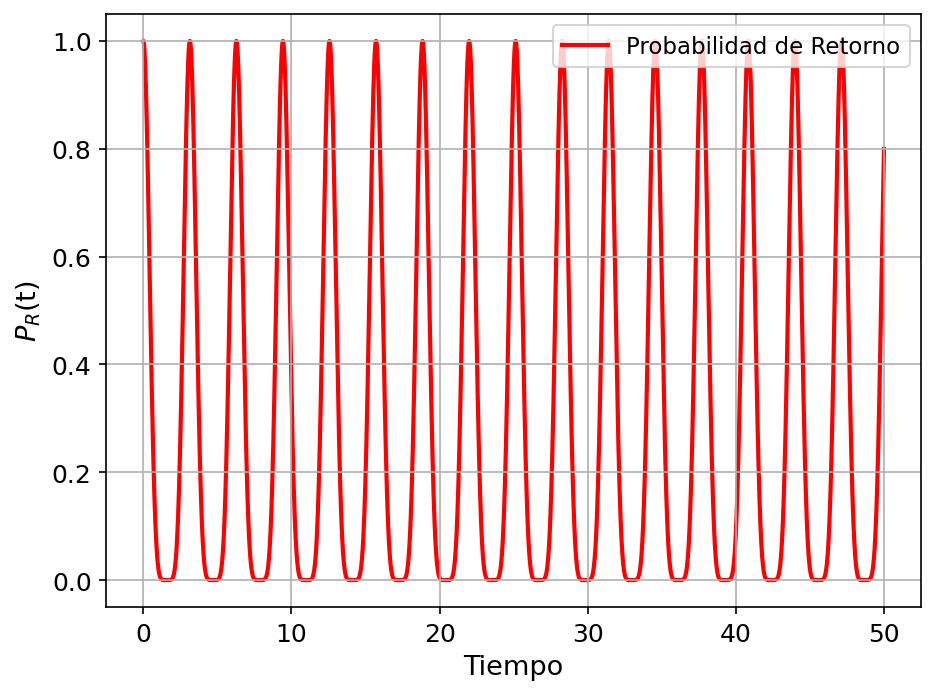

In [4]:
#Caso 1

B=0.01*J
Hamiltoniano=H(N, J, B)
ProbRetorno=Ev(Hamiltoniano, psi0, listat)

#Graficos

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 12,
    "axes.labelsize": 13,
    "legend.fontsize": 11,
    "axes.grid": True,
})

plt.figure()

plt.plot(listat, ProbRetorno, label="Probabilidad de Retorno", linewidth=2, color='red', zorder=1)

plt.xlabel("Tiempo")
plt.ylabel("$P_{R}$(t)")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

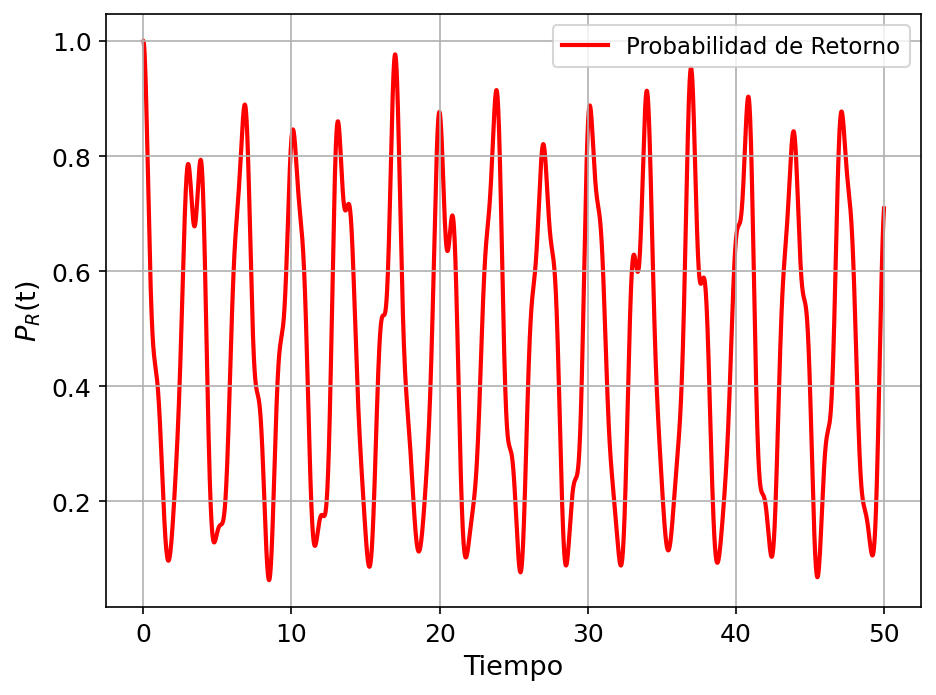

In [26]:
#Caso 2

B=J
Hamiltoniano=H(N, J, B)
ProbRetorno=Ev(Hamiltoniano, psi0, listat)

#Graficos

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 12,
    "axes.labelsize": 13,
    "legend.fontsize": 11,
    "axes.grid": True,
})

plt.figure()

plt.plot(listat, ProbRetorno, label="Probabilidad de Retorno", linewidth=2, color='red', zorder=1)

plt.xlabel("Tiempo")
plt.ylabel("$P_{R}$(t)")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

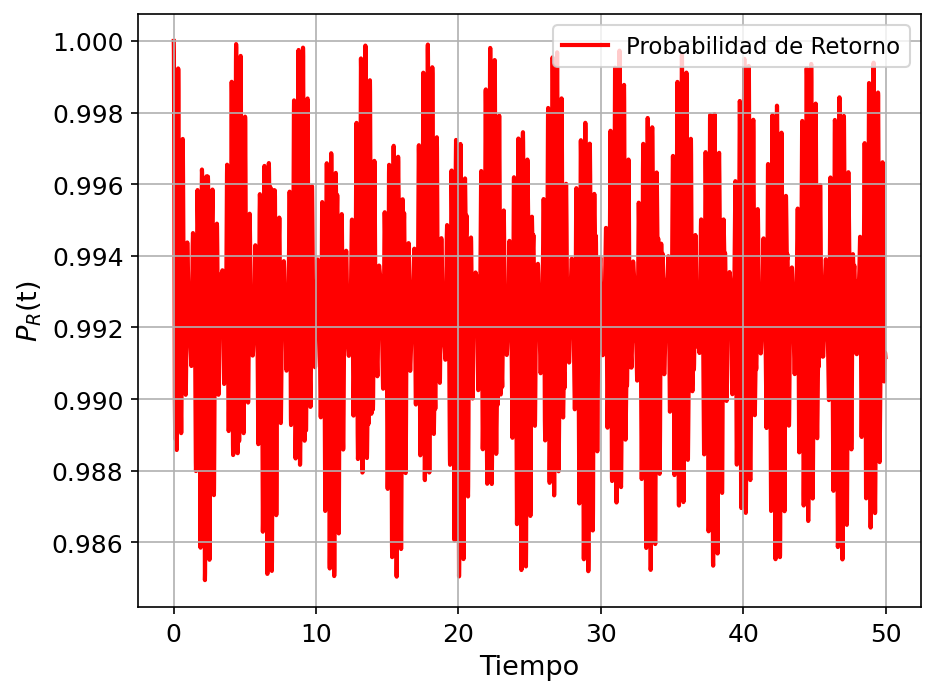

In [28]:
#Caso 3

B=10*J
Hamiltoniano=H(N, J, B)
ProbRetorno=Ev(Hamiltoniano, psi0, listat)

#Graficos

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 12,
    "axes.labelsize": 13,
    "legend.fontsize": 11,
    "axes.grid": True,
})

plt.figure()

plt.plot(listat, ProbRetorno, label="Probabilidad de Retorno", linewidth=2, color='red', zorder=1)

plt.xlabel("Tiempo")
plt.ylabel("$P_{R}$(t)")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

(d)  Mida el tiempo de calculo necesario para construir y diagonalizar el Hamiltoniano para
distintos tamanos del sistema (N = 4, 5, 6, 7, 8):

In [ ]:
import time

Espines=[4, 5, 6, 7, 8, 9, 10]                    #Cadenas con distintos espines (lo hice desde 4 a 10 porque no notaba gran diferencia de 4 a 8)
B=J                                        #Por simplicidad escogemos B=J

#Arreglo de tiempos

t_const=[]                                 #Lista vacia para introducir tiempos de construccion
t_diag=[]                                  

#Ciclo para analizar cada cadena

for i in Espines:

    #Medicion de tiempo construccion de Hamiltoniano

    tic1=time.time()                           #Inicializa el tiempo de ejecucion
    Hamiltoniano=H(i, J, B)
    tic2=time.time()                           #Finaliza el tiempo de ejecucion
    t_const.append(tic2-tic1)                  #Agrego tiempo de construccion de H a la lista

    #Medicion de tiempo de diagonalizacion de Hamiltoniano

    tic3= time.time()    
    autovalores, autovectores = np.linalg.eigh(Hamiltoniano)    #np.linalg.eigh diagonaliza una matriz
    tic4=time.time()  
    t_diag.append(tic4-tic3)                     

#Tiempos de ejecucion

for i in range(len(Espines)):                   #Ciclo que toma cada tiempo de construccion y diagonalizacion por cada N
    N = Espines[i]                              #Elijo la posicion i de la lista Espines
    t_c = t_const[i]
    t_d = t_diag[i]
    
    print("N =", N)
    print("Tiempo construcción =", t_c, "s")
    print("Tiempo diagonalización =", t_d, "s")
    print("---------------------------")

N = 4
Tiempo construcción = 0.002761363983154297 s
Tiempo diagonalización = 0.0016474723815917969 s
---------------------------
N = 5
Tiempo construcción = 0.002069234848022461 s
Tiempo diagonalización = 0.00042700767517089844 s
---------------------------
N = 6
Tiempo construcción = 0.004617452621459961 s
Tiempo diagonalización = 0.0011708736419677734 s
---------------------------
N = 7
Tiempo construcción = 0.010678529739379883 s
Tiempo diagonalización = 0.006571769714355469 s
---------------------------
N = 8
Tiempo construcción = 0.0339198112487793 s
Tiempo diagonalización = 0.03850984573364258 s
---------------------------
N = 9
Tiempo construcción = 0.14414429664611816 s
Tiempo diagonalización = 0.1461014747619629 s
---------------------------
N = 10
Tiempo construcción = 0.5957574844360352 s
Tiempo diagonalización = 1.0439951419830322 s
---------------------------


(e) Grafique el tiempo de ejecucion en funcion de N (recuerde promediar varias realizaciones).  

Para hacer esto utilizare el mismo codigo anterior pero realizare mas veces por cada cadena y promediare.

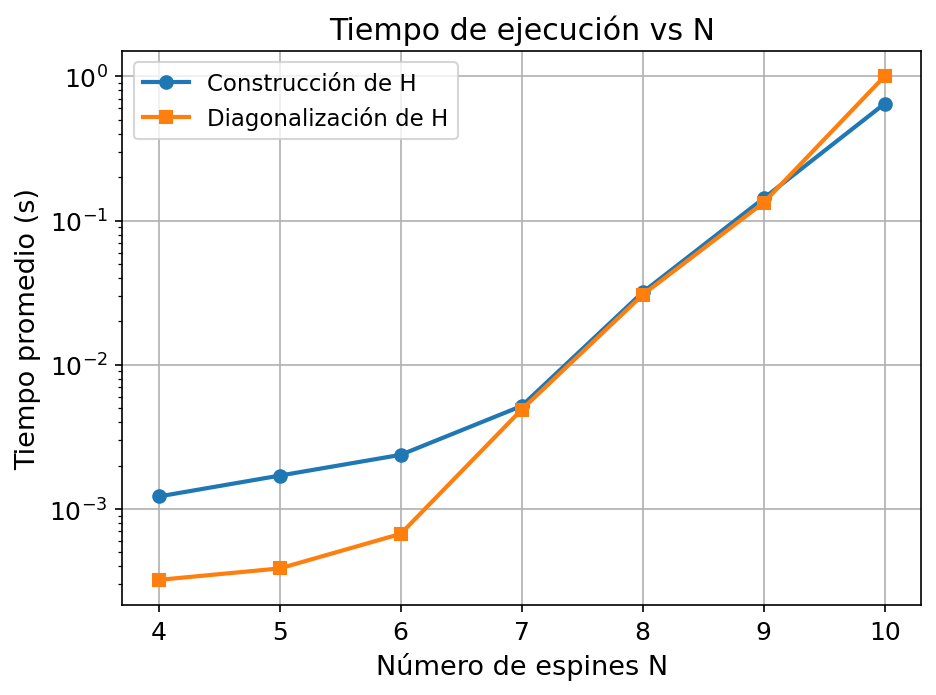

In [38]:
#Realizaciones

R=10

#Arreglo de tiempos

t_const=[]                                 
t_diag=[] 

#Ciclo para analizar cada cadena

for i in Espines:
    
    #Arreglo de tiempos

    t_const_R=[]                                 
    t_diag_R=[] 

    for j in range(R):

        #Medicion de tiempo construccion de Hamiltoniano

        tic1=time.time()                           #Inicializa el tiempo de ejecucion
        Hamiltoniano=H(i, J, B)
        tic2=time.time()                           #Finaliza el tiempo de ejecucion
        t_const_R.append(tic2-tic1)                  #Agrego tiempo de construccion de H a la lista

        #Medicion de tiempo de diagonalizacion de Hamiltoniano

        tic3= time.time()    
        autovalores, autovectores = np.linalg.eigh(Hamiltoniano)    #np.linalg.eigh diagonaliza una matriz
        tic4=time.time()  
        t_diag_R.append(tic4-tic3)  

    #Promedio por N

    Prom_const=np.mean(t_const_R)
    Prom_diag=np.mean(t_diag_R)
    t_const.append(Prom_const) 
    t_diag.append(Prom_diag)                

#Graficos

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 12,
    "axes.labelsize": 13,
    "legend.fontsize": 11,
    "axes.grid": True,
})

plt.figure()

plt.plot(Espines, t_const, label="Construcción de H", linewidth=2, marker='o', zorder=2)
plt.plot(Espines, t_diag, label="Diagonalización de H", linewidth=2, marker='s', zorder=3)

plt.xlabel("Número de espines N")
plt.ylabel("Tiempo promedio (s)")
plt.title("Tiempo de ejecución vs N")

plt.legend(loc="upper left")
plt.yscale("log")                     #Utilizo escala logaritmica

plt.tight_layout()
plt.show()

(f) Utilizando los tiempos obtenidos, estime cuanto demorarıa la simulacion para N = 20, N = 50 y N = 100 espines. No simule estos casos, ya que por construccion no tendra la memoria suficiente.

De forma general, una matriz de dimensión $d$ posee $d^{2}$ elementos. En operaciones como el producto de matrices, cada uno de estos elementos requiere del orden de $d$ operaciones (producto fila por columna). Por ejemplo, para matrices de dimensión $3$:

$$
C_{11} = A_{11}B_{11} + A_{12}B_{21} + A_{13}B_{31}
$$

Por lo tanto, el número total de operaciones escala como:

$$
d^{2} \cdot d = d^{3}
$$

Así, la diagonalización de una matriz de dimensión $2^{N}$ tiene un costo computacional que escala como:

$$
T(N) \propto (2^{N})^{3} = 2^{3N}
$$

Utilizando como referencia el tiempo medido para $N=10$, del orden de:

$$
T(10) \approx 1 \text{ s}
$$

se puede estimar:

$$
\frac{T(N)}{T(10)} = 2^{3(N-10)}  
$$  
$$
T(N) = T(10) \cdot 2^{3(N-10)}
$$

De esta forma:

$$
T(20) \approx 2^{30} \approx 10^{9} \text{ s}
$$

$$
T(50) \approx 2^{120} \approx 10^{36} \text{ s}
$$

$$
T(100) \approx 2^{270} \approx 10^{81} \text{ s}
$$

(g)  Compare su estimacion en (f) con la edad del universo (≈ 4,3 × 10^{17} segundos).

La edad del universo es aproximadamente:

$$
T_u \approx 4.3 \times 10^{17} \text{ s}
$$

Comparando:

- Para $N=20$:
$$
\frac{T(20)}{T_u} \approx \frac{10^{9}}{10^{17}} = 10^{-8}
$$
Un tiempo bastante menor a la edad del universo, pero para nada despreciable.

- Para $N=50$:
$$
\frac{T(50)}{T_u} \approx 10^{19}
$$

- Para $N=100$:
$$
\frac{T(100)}{T_u} \approx 10^{64}
$$

En los casos $N=50$ y $N=100$, los tiempos de ejecución superan muchisimo la edad del universo, lo que indica que, de manera clasica, es imposible obtener estos calculos

(h) Discuta por que este crecimiento exponencial del espacio de Hilbert representa uno de los principales desafıos para la simulacion clasica de sistemas cuanticos de muchos cuerpos.

El crecimiento exponencial del espacio de Hilbert radica en como escala su dimensionalidad. En este caso particular para una cadena de espinas escala $2^{N}$, lo que limita fuertemente el analisis de sistemas mas amplios. Solamente con $20$ espines la escala temporal es del orden de decadas, y esta cantidad de espines es un numero bastante bajo considerando que la estructura de la materia tiene muchisimos mas. Por ende, se concluye que este enfoque clasico de simulacion es inviable para tratar sistemas cuanticosde muchos cuerpos.
